# 05 · Kendi modelimi eğitmek (Aşama 6–7)

Hazır model kuşbakışı termal görüntülerde çalışmamıştı (arabaya "cell phone" diyordu) ve drone / mine / gun sınıflarını hiç tanımıyordu. Bu yüzden kendi modelimizi eğittik.

**Eğitim Kaggle'da, ücretsiz Tesla T4 GPU ile yapıldı.** Aşağıdaki 1–4. bölümler Kaggle notebook'unda çalıştırıldı, burada kayıt olarak duruyor. 5. bölümden itibaren kod bu bilgisayarda çalışır.

| | |
|---|---|
| Model | `yolo11n` (hazır modelden devam — transfer öğrenme) |
| Eğitim verisi | 3.000 fotoğraf (train), 600 fotoğraf (val) |
| Epoch | 20 |
| Görüntü boyutu | 640 |
| Batch | 32 |
| Süre | ~20 dakika |
| Sonuç | **mAP50 = 0.789**, mAP50-95 = 0.554 |

## 1. Kaggle'da hazırlık (orada çalıştırıldı)

```python
import torch
print(torch.cuda.is_available())        # True
print(torch.cuda.get_device_name(0))    # Tesla T4
```

Not: Kaggle notebook'unda **Internet** ayarı açık olmalı, yoksa `pip install` çalışmaz.

```python
!pip install -q ultralytics
```

## 2. Eğitim verisini hazırlama (Kaggle'da)

20 bin fotoğrafın tamamı yerine 3.000 fotoğrafla başladık. Fotoğraflar kopyalanmadı, **kısayol (symlink)** oluşturuldu: 5 GB'lık gereksiz kopya yok, saniyeler içinde hazırlanıyor.

```python
import os, random

kok = "/kaggle/input/datasets/umuttuygurr/aerial-uav-thermal-inferred-unified-dataset/merged_uav_dataset"
hedef = "/kaggle/working/egitim_verisi"

for bolum, adet in [("train", 3000), ("val", 600)]:
    dosyalar = sorted(os.listdir(kok + "/images/" + bolum))   # bütün fotoğraf adları
    random.seed(42)                                          # seçim tekrarlanabilir olsun
    random.shuffle(dosyalar)                                 # karıştır (hep aynı kaynaktan gelmesin)
    secilenler = dosyalar[:adet]                             # ilk 'adet' tanesi

    os.makedirs(hedef + "/images/" + bolum, exist_ok=True)
    os.makedirs(hedef + "/labels/" + bolum, exist_ok=True)

    sayac = 0
    for dosya_adi in secilenler:
        ad = dosya_adi.rsplit(".", 1)[0]                     # uzantıyı at
        etiket = kok + "/labels/" + bolum + "/" + ad + ".txt"
        if os.path.exists(etiket):                           # etiketi olanları al
            os.symlink(kok + "/images/" + bolum + "/" + dosya_adi,
                       hedef + "/images/" + bolum + "/" + dosya_adi)
            os.symlink(etiket, hedef + "/labels/" + bolum + "/" + ad + ".txt")
            sayac = sayac + 1

    print(bolum, sayac)      # train 3000 / val 600
```

## 3. `data.yaml` (Kaggle'da)

YOLO'ya "veri nerede, sınıflar ne" bilgisini veren dosya. Etiketlerin yerini yazmaya gerek yok: YOLO `images` yerine `labels` klasörüne bakar.

```python
icerik = """path: /kaggle/working/egitim_verisi
train: images/train
val: images/val

nc: 7
names:
  0: person
  1: car
  2: bicycle
  3: other_vehicle
  4: drone
  5: mine
  6: gun
"""

with open("/kaggle/working/data.yaml", "w") as dosya:    # "w" = yazma modu
    dosya.write(icerik)
```

## 4. Eğitim (Kaggle'da)

```python
from ultralytics import YOLO

model = YOLO("yolo11n.pt")              # hazır modelden başla (transfer öğrenme)

sonuc = model.train(
    data="/kaggle/working/data.yaml",
    epochs=20,                          # veri 20 kez baştan sona gösterilir
    imgsz=640,                          # fotoğraflar 640 piksele ölçeklenir
    batch=32,                           # 32 fotoğraf birlikte işlenir, sonra bir düzeltme
    device=0,                           # 0 = birinci GPU
    project="/kaggle/working/egitim",
    name="deneme1",
)
```

**Eğitim döngüsü (özet):** tahmin → gerçek etiketle karşılaştır → hata (loss) → 2,5 milyon parametreyi azıcık düzelt. 3000 ÷ 32 = 94 adım/epoch, 20 epoch = **1.880 düzeltme adımı**.

Sonuçta `best.pt` (val sınavında en iyi epoch) ve `last.pt` (son epoch) kaydedilir. Biz `best.pt` dosyasını indirip `models/iha_yolo11n.pt` adıyla projeye koyduk.

## 5. Eğitim sonuçları

```
all    600 fotoğraf   1931 nesne   P 0.879   R 0.719   mAP50 0.789   mAP50-95 0.554
```

| Sınıf | Doğrulamadaki nesne | mAP50 | Yorum |
|---|---|---|---|
| mine | 41 | 0.991 | En iyi — ama tek kaynaktan geldiği için "kestirme öğrenme" şüphesi var |
| gun | 38 | 0.978 | |
| drone | 69 | 0.938 | |
| person | 1404 | 0.930 | |
| car | 321 | 0.926 | |
| bicycle | 52 | 0.627 | En küçük nesneler (tipik kenar 25 px) |
| **other_vehicle** | 6 | **0.133** | Recall 0 — hiçbirini bulamadı, veri setinde sadece 148 örnek var |

**Not:** `other_vehicle` ve `bicycle` için doğrulamada çok az örnek var (6 ve 52 nesne), bu sınıfların sayıları istatistiksel olarak güvenilir değil.

### Eğitim grafikleri (`egitim_sonuclari/`)

**`results.png`** — loss ve metrik eğrileri
- Hem train hem val loss düzenli düşüyor → **ezberleme (overfitting) yok**
- mAP50: 0.37 → 0.79, mAP50-95: 0.22 → 0.55
- Eğriler 20. epoch'ta **hâlâ yükseliyor** → daha uzun eğitim daha iyi sonuç verir

**`confusion_matrix.png`** — hangi sınıf hangisiyle karışıyor
- `other_vehicle` sınıfı için model hiç tahmin yapmamış; gerçekteki 6 nesnenin 4'üne **car** demiş
- Sınıflar arası başka karışıklık neredeyse yok
- Hatalar çoğunlukla **yanlış alarm** (248 person) ve **kaçırma** (114 person) şeklinde

In [1]:
import matplotlib.pyplot as plt

def grafik_goster(dosya, baslik, boyut=(15, 7)):
    resim = plt.imread("../egitim_sonuclari/" + dosya)   # kaydedilmiş grafiği oku
    plt.figure(figsize=boyut)
    plt.imshow(resim)
    plt.title(baslik)
    plt.axis("off")
    plt.show()

#### Eğitim eğrileri
Üst sıra eğitim (train), alt sıra doğrulama (val) verisi. Yatay eksen epoch.

**Okurken bakılacaklar:**
- İlk 3 sütun **kayıp (loss)**: hem train hem val düşüyor → model öğreniyor ve **ezberlemiyor**. Val loss yükselmeye başlasaydı ezberleme (overfitting) olurdu.
- **Precision** 1. epoch'ta 0.98'den 0.74'e düşüyor: model başta ürkekti, az kutu çizip hepsini tutturuyordu. Sonra çok kutu çizmeye başladı.
- **Recall** 0.14 → 0.72: kaçırdığı nesne sayısı sürekli azaldı.
- **mAP50** 0.37 → 0.79 ve **hâlâ yükseliyor** → eğitim erken bitti, daha uzun eğitim daha iyi sonuç verir.

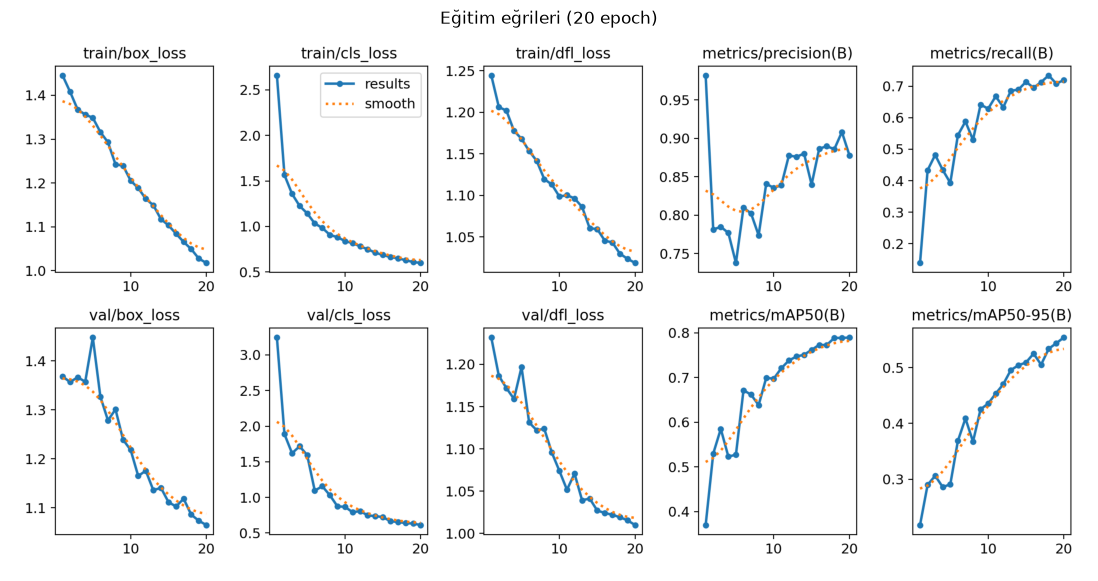

In [2]:
grafik_goster("results.png", "Eğitim eğrileri (20 epoch)")

#### Karışıklık matrisi
Alt eksen **gerçek** sınıf, sol eksen **modelin tahmini**. Köşegen doğru bilinenler.

**Bulgular:**
- Köşegen: person 1290, car 281, drone 65, mine 41, bicycle 38, gun 38 doğru
- **`other_vehicle` satırı tamamen boş** → model bu sınıfı hiç kullanmamış. Gerçekteki 6 nesnenin **4'üne `car`** demiş.
- Sınıflar arası başka karışıklık neredeyse yok.
- Son sütun (background): 248 kez olmayan insan görmüş → **yanlış alarm (FP)**
- Son satır (background): 114 gerçek insanı kaçırmış → **kaçırma (FN)**

Yani hatalar sınıfları karıştırmaktan değil, olmayanı görmek ve olanı kaçırmaktan geliyor.

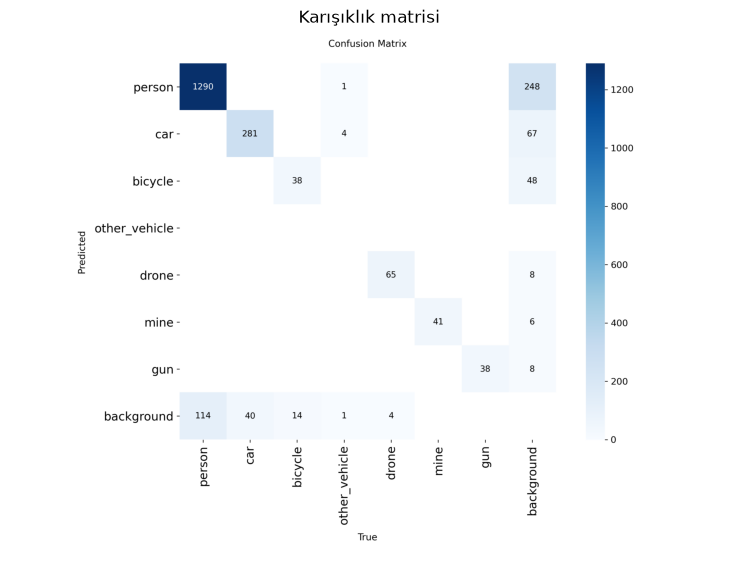

In [3]:
grafik_goster("confusion_matrix.png", "Karışıklık matrisi")

#### Doğrulama fotoğraflarındaki tahminler
Modelin hiç görmediği val fotoğraflarında çizdiği kutular.

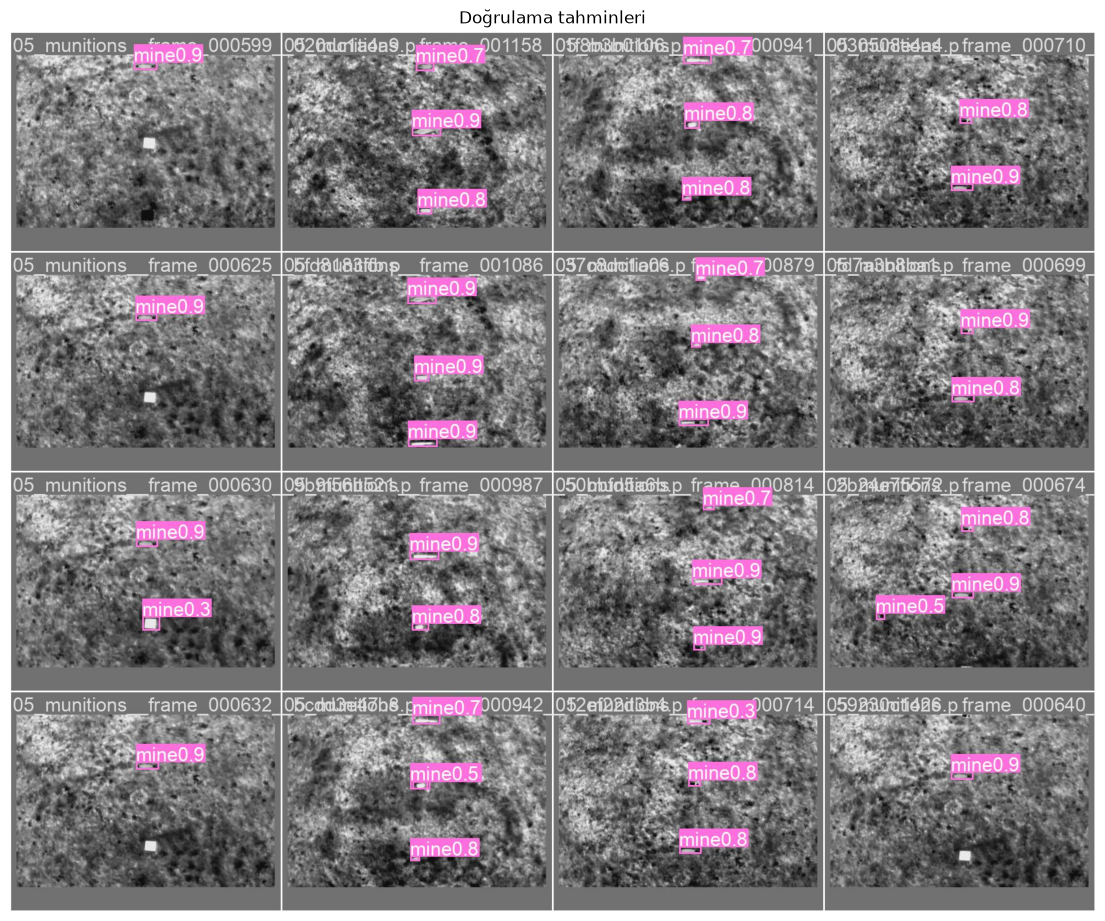

In [4]:
grafik_goster("val_batch0_pred.jpg", "Doğrulama tahminleri", boyut=(14, 14))

## 6. Eğitilmiş modeli burada kullanmak
Aşağıdaki hücreler bu bilgisayarda çalışır.

In [5]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

hazir = YOLO("../models/yolo11n.pt")          # COCO ile eğitilmiş hazır model
benim = YOLO("../models/iha_yolo11n.pt")      # bizim eğittiğimiz model

print("hazır modelin sınıf sayısı:", len(hazir.names))
print("bizim modelin sınıfları   :", benim.names)

hazır modelin sınıf sayısı: 80
bizim modelin sınıfları   : {0: 'person', 1: 'car', 2: 'bicycle', 3: 'other_vehicle', 4: 'drone', 5: 'mine', 6: 'gun'}


### Karşılaştırma fonksiyonu
Aynı fotoğrafı iki modele de verip sonuçları yan yana gösterir.

In [6]:
def karsilastir(ad, bolum):
    yol = "../data/kucuk_paket/images/" + bolum + "/" + ad + ".png"

    fig, eksenler = plt.subplots(1, 2, figsize=(16, 7))

    for eksen, model, baslik in [(eksenler[0], hazir, "Hazır model (COCO)"),
                                 (eksenler[1], benim, "Bizim modelimiz")]:
        sonuc = model(yol, verbose=False)[0]              # modeli çalıştır
        cizim = sonuc.plot()                              # kutuları çiz (BGR)
        eksen.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
        eksen.set_title(baslik + "  —  " + str(len(sonuc.boxes)) + " kutu")
        eksen.axis("off")

    plt.tight_layout()
    plt.show()

### Deneme 1: kuşbakışı termal otopark
Gerçekte 20 car + 1 other_vehicle var.

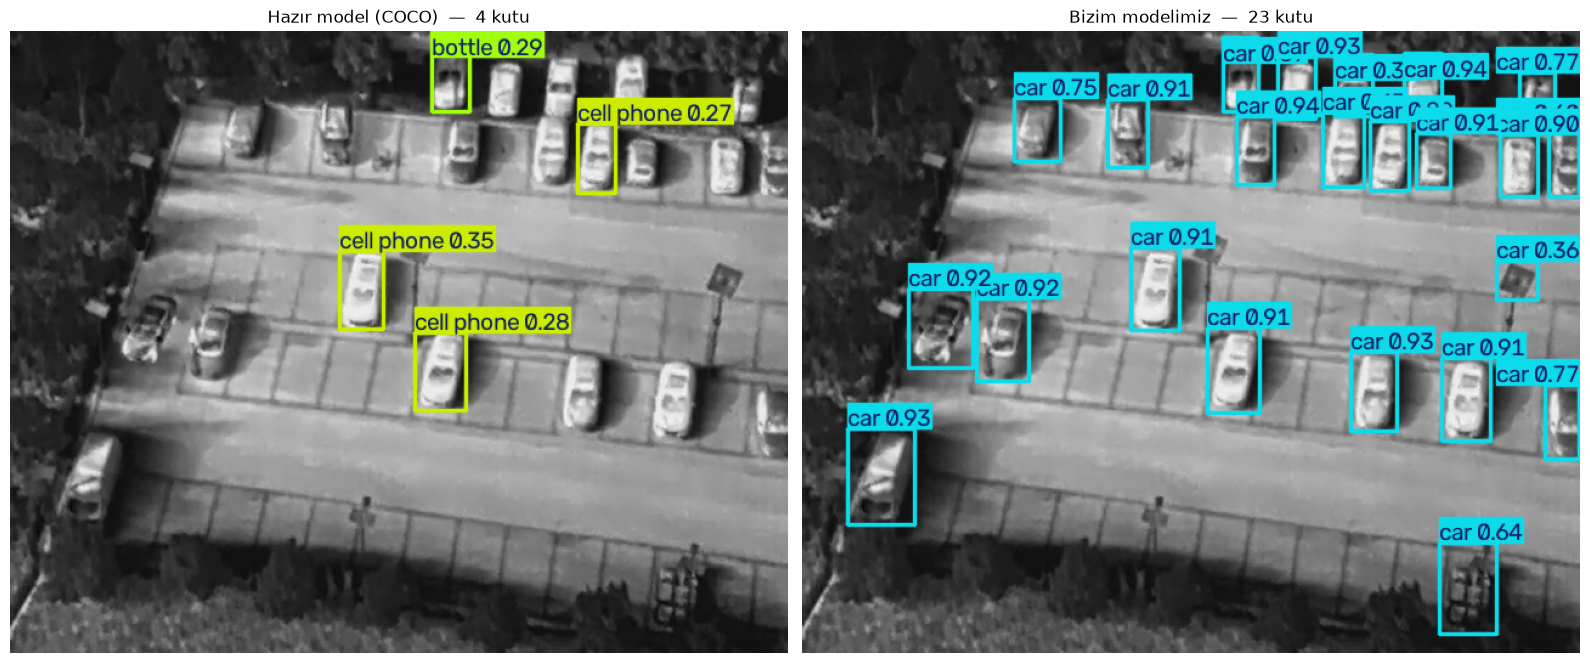

In [7]:
karsilastir("02_hituav__0_100_50_0_08164__c5427da128", "train")

### Deneme 2: sokak seviyesinden termal görüntü
Gerçekte 3 car + 5 person var.

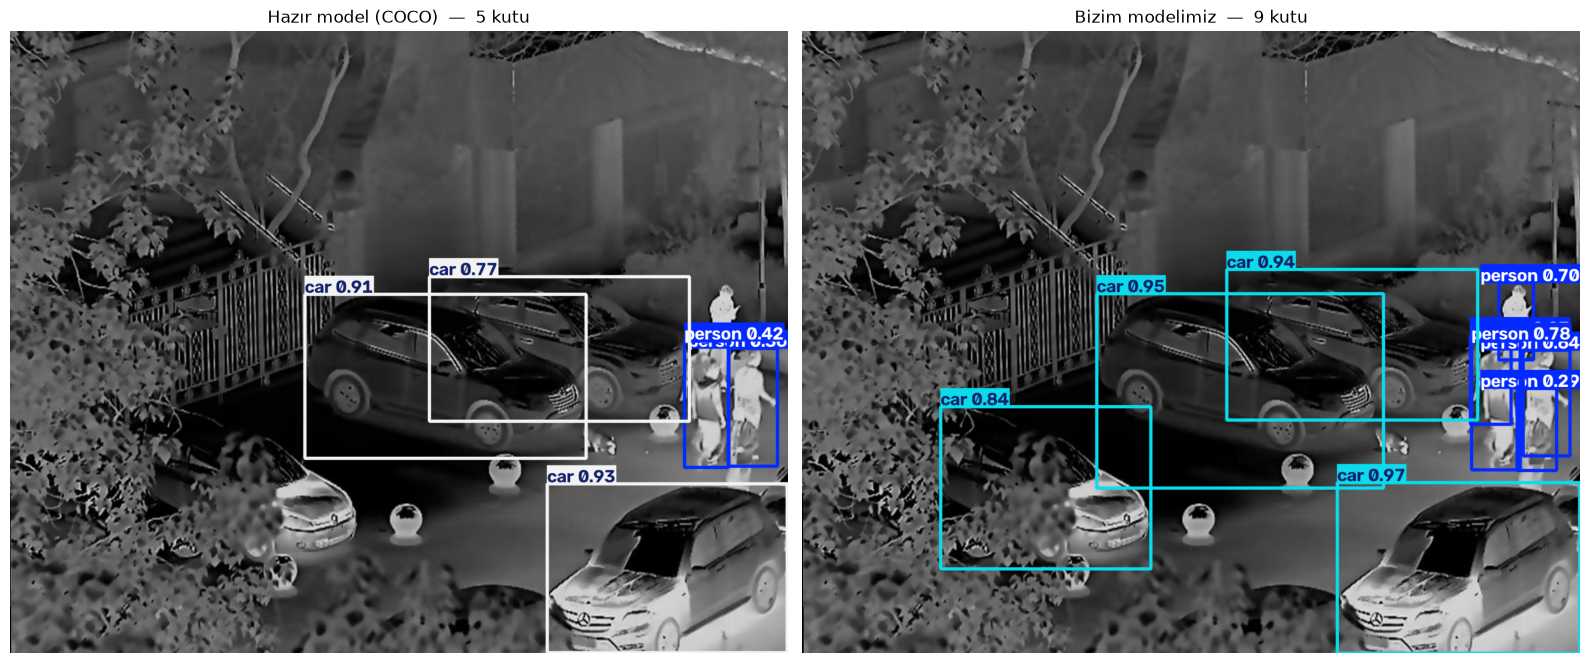

In [8]:
karsilastir("03_llvip__120019__91781a1c2d", "train")

### Deneme 3: gökyüzünde İHA
Gerçekte 2 drone var. Hazır model bu sınıfı hiç tanımıyor.

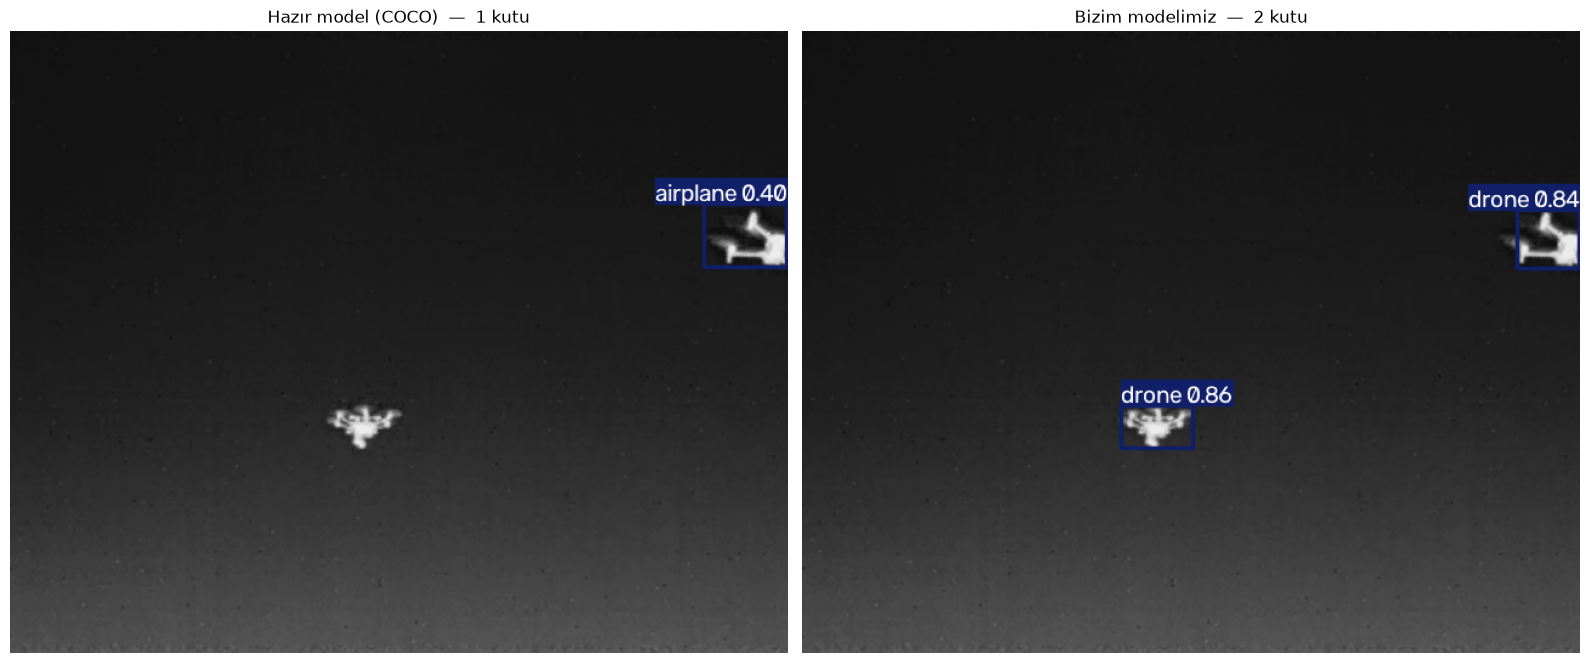

In [9]:
karsilastir("01_uav2uav__430__864a7aebf1", "train")

## Sonuç

| Fotoğraf | Hazır model | Bizim modelimiz |
|---|---|---|
| Kuşbakışı otopark (21 nesne) | 4 kutu: *cell phone*, *bottle* | **23 araç**, çoğu 0.90+ güvenle |
| Sokak termal (8 nesne) | 3 car + 2 person | **4 car + 5 person** |
| Gökyüzünde İHA (2 nesne) | sınıfı bilmiyor | **2 drone** |

20 dakikalık bir eğitimle, hazır modelin hiç yapamadığı iş yapılabilir hale geldi.

### Sonraki adımlar
1. **`other_vehicle`**: daha fazla örnek toplanmalı ya da `car` ile birleştirilmeli (148 örnekle öğrenilmiyor)
2. **Daha uzun eğitim**: mAP eğrileri hâlâ yükseliyordu; 50+ epoch ve daha çok veri denenmeli
3. **Kestirme öğrenme testi**: her sınıf tek bir kaynaktan geldiği için model nesneyi mi, fotoğrafın türünü mü tanıyor?